In [32]:
import json
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
FILE_PATH = '/mnt/sda3/dataset_AMC /radioml2018/versions/2/GOLD_XYZ_OSC.0001_1024.hdf5'
JSON_PATH = '/mnt/sda3/dataset_AMC /radioml2018/versions/2/classes-fixed.json'

In [3]:
with open(JSON_PATH, 'r') as f:
    fixed_classes = json.load(f)

print(f"Found {len(fixed_classes)} modulations:\n", fixed_classes)

Found 24 modulations:
 ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']


In [43]:
# --- Parameters for selecting THE ONE FRAME ---
# Ensure FILE_PATH is correctly defined in your environment
# Example: FILE_PATH = 'path/to/your/RadioML2018.01A.h5'
if 'FILE_PATH' not in locals():
    raise ValueError("FILE_PATH is not defined. Please set the path to your HDF5 dataset.")

modulation_to_select = 'BPSK'
snr_to_select = 30 # You can change this SNR level

# --- Key Parameter: True Samples Per Symbol for BPSK in RadioML2018.A ---
true_sps = 8

# --- Helper function placeholder (ensure this is correctly defined) ---
def find_modulation_snr_indices(mod, snr, classes_list, y_labels_array, z_snr_array):
    """
    Finds indices for a given modulation string and SNR.
    Placeholder - adapt to your actual label format and loading.
    """
    print("Warning: Using placeholder 'find_modulation_snr_indices'. Adapt to your data.")
    mod_target_str = mod
    mod_match_flags = np.zeros(len(y_labels_array), dtype=bool)
    for i, label_from_y in enumerate(y_labels_array):
        current_label_str = label_from_y.decode('utf-8') if isinstance(label_from_y, bytes) else str(label_from_y)
        if current_label_str == mod_target_str:
            mod_match_flags[i] = True
    mod_indices = np.where(mod_match_flags)[0]
    snr_match_indices = np.where(z_snr_array == snr)[0]
    common_indices = np.intersect1d(mod_indices, snr_match_indices)
    return common_indices.tolist()

# --- Load Labels and SNRs (Crucial and dataset-specific) ---
try:
    with h5py.File(FILE_PATH, 'r') as f:
        if 'Y' in f and 'Z' in f:
            Y_arr_raw = f['Y'][:]
            Z_arr = f['Z'][:, 0]
            if 'fixed_classes' not in globals() or fixed_classes is None:
                fixed_classes = ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-DSB-WC', 'AM-DSB-SC', 'AM-SSB-WC', 'AM-SSB-SC', 'FM', 'GMSK', 'OQPSK']
            if Y_arr_raw.ndim == 2: # One-hot encoded
                Y_arr_int_labels = np.argmax(Y_arr_raw, axis=1)
                Y_arr = np.array([fixed_classes[i] for i in Y_arr_int_labels])
            else:
                 Y_arr = np.array([label.decode('utf-8') if isinstance(label, bytes) else str(label) for label in Y_arr_raw])
            if 'fixed_classes' not in globals() or fixed_classes is None:
                fixed_classes = np.unique(Y_arr).tolist()
        else:
            raise KeyError("Y or Z dataset not found in HDF5 file.")
except Exception as e:
    print(f"Error loading or processing Y/Z from HDF5: {e}.")
    if 'Y_arr' not in locals(): Y_arr = np.array(['BPSK'])
    if 'Z_arr' not in locals(): Z_arr = np.array([20])
    if 'fixed_classes' not in locals(): fixed_classes = ['BPSK']

# --- Find the specific index ---
idxs = find_modulation_snr_indices(modulation_to_select, snr_to_select, fixed_classes, Y_arr, Z_arr)
if len(idxs) == 0:
    raise ValueError(f"No sample found for {modulation_to_select} / {snr_to_select}dB combination.")
sample_idx_to_load = idxs[0]
print(f"Analyzing Frame Index: {sample_idx_to_load} ({modulation_to_select} @ {snr_to_select}dB)")

# --- Load I/Q data for THE ONE selected frame ---
with h5py.File(FILE_PATH, 'r') as f:
    X_ds = f['X']
    one_frame_iq = X_ds[sample_idx_to_load, :, :]

I_full_frame = one_frame_iq[:, 0]
Q_full_frame = one_frame_iq[:, 1]

# --- Function to calculate energy per symbol for constellation analysis ---
def calculate_symbol_energy_constellation(I_frame_data, Q_frame_data, sps_val):
    """
    Calculates the energy per symbol and returns constellation points.
    For BPSK, this integrates energy over the symbol period (8 samples).
    
    This approach follows the theoretical principle that symbol detection 
    should be based on the integrated energy over the entire symbol duration.
    
    Args:
        I_frame_data (np.array): I component samples for the entire frame.
        Q_frame_data (np.array): Q component samples for the entire frame.
        sps_val (int): Samples per symbol (8 for this dataset).
    Returns:
        tuple: (I_constellation, Q_constellation) - energy-based constellation points
    """
    # Ensure we have complete symbols
    min_length = min(len(I_frame_data), len(Q_frame_data))
    if min_length % sps_val != 0:
        num_total_samples_frame = (min_length // sps_val) * sps_val
        I_frame_data = I_frame_data[:num_total_samples_frame]
        Q_frame_data = Q_frame_data[:num_total_samples_frame]
        print(f"Warning: Frame length truncated to {num_total_samples_frame} for even symbol division.")

    num_symbols_frame = len(I_frame_data) // sps_val
    print(f"Processing {num_symbols_frame} symbols with {sps_val} samples per symbol")
    
    # Reshape both I and Q data into (num_symbols, sps_val) matrices
    I_reshaped = I_frame_data.reshape(num_symbols_frame, sps_val)
    Q_reshaped = Q_frame_data.reshape(num_symbols_frame, sps_val)
    
    # Calculate energy per symbol by averaging over the symbol period
    # This integrates the signal energy over the 8-sample symbol duration
    I_constellation = np.mean(I_reshaped, axis=1)  # Average I per symbol
    Q_constellation = np.mean(Q_reshaped, axis=1)  # Average Q per symbol
    
    return I_constellation, Q_constellation

def calculate_symbol_rms_energy(I_frame_data, Q_frame_data, sps_val):
    """
    Calculates the RMS (Root Mean Square) energy per symbol for both components.
    This provides a measure of the signal power within each symbol period.
    
    Args:
        I_frame_data (np.array): I component samples.
        Q_frame_data (np.array): Q component samples.
        sps_val (int): Samples per symbol.
    Returns:
        tuple: (I_rms_energy, Q_rms_energy, total_rms_energy)
    """
    if len(I_frame_data) % sps_val != 0:
        num_total_samples_frame = (len(I_frame_data) // sps_val) * sps_val
        I_frame_data = I_frame_data[:num_total_samples_frame]
        Q_frame_data = Q_frame_data[:num_total_samples_frame]

    num_symbols_frame = len(I_frame_data) // sps_val
    
    # Reshape the data into (num_symbols, sps_val) matrices
    I_reshaped = I_frame_data.reshape(num_symbols_frame, sps_val)
    Q_reshaped = Q_frame_data.reshape(num_symbols_frame, sps_val)
    
    # Calculate RMS energy per symbol: sqrt(mean(samples^2))
    I_rms_energy = np.sqrt(np.mean(I_reshaped**2, axis=1))
    Q_rms_energy = np.sqrt(np.mean(Q_reshaped**2, axis=1))
    
    # Total energy per symbol
    total_rms_energy = np.sqrt(I_rms_energy**2 + Q_rms_energy**2)
    
    return I_rms_energy, Q_rms_energy, total_rms_energy

Analyzing Frame Index: 421888 (BPSK @ 30dB)


In [44]:
# --- Calculate BPSK Constellation using Energy per Symbol ---
print(f"\n--- BPSK Constellation Analysis using Energy per Symbol (sps={true_sps}) ---")

# Calculate constellation points using energy integration method
I_constellation, Q_constellation = calculate_symbol_energy_constellation(I_full_frame, Q_full_frame, true_sps)

print(f"Number of constellation points: {len(I_constellation)}")
print(f"\nI-component statistics:")
print(f"  Mean: {np.mean(I_constellation):.4f}")
print(f"  Std:  {np.std(I_constellation):.4f}")
print(f"  Range: [{np.min(I_constellation):.4f}, {np.max(I_constellation):.4f}]")

print(f"\nQ-component statistics:")
print(f"  Mean: {np.mean(Q_constellation):.4f}")
print(f"  Std:  {np.std(Q_constellation):.4f}")
print(f"  Range: [{np.min(Q_constellation):.4f}, {np.max(Q_constellation):.4f}]")

# Calculate RMS energy analysis
I_rms_energy, Q_rms_energy, total_rms_energy = calculate_symbol_rms_energy(I_full_frame, Q_full_frame, true_sps)

print(f"\nRMS Energy Analysis:")
print(f"I RMS Energy - Mean: {np.mean(I_rms_energy):.4f}, Std: {np.std(I_rms_energy):.4f}")
print(f"Q RMS Energy - Mean: {np.mean(Q_rms_energy):.4f}, Std: {np.std(Q_rms_energy):.4f}")
print(f"Total RMS Energy - Mean: {np.mean(total_rms_energy):.4f}, Std: {np.std(total_rms_energy):.4f}")

# --- BPSK Energy-based Constellation Plot ---
print(f"\n--- Creating BPSK Energy-based Constellation Plot ---")


--- BPSK Constellation Analysis using Energy per Symbol (sps=8) ---
Processing 128 symbols with 8 samples per symbol
Number of constellation points: 128

I-component statistics:
  Mean: -0.0066
  Std:  0.1198
  Range: [-0.1892, 0.1814]

Q-component statistics:
  Mean: -0.0501
  Std:  0.9062
  Range: [-1.3814, 1.3824]

RMS Energy Analysis:
I RMS Energy - Mean: 0.1277, Std: 0.0359
Q RMS Energy - Mean: 0.9659, Std: 0.2708
Total RMS Energy - Mean: 0.9743, Std: 0.2732

--- Creating BPSK Energy-based Constellation Plot ---


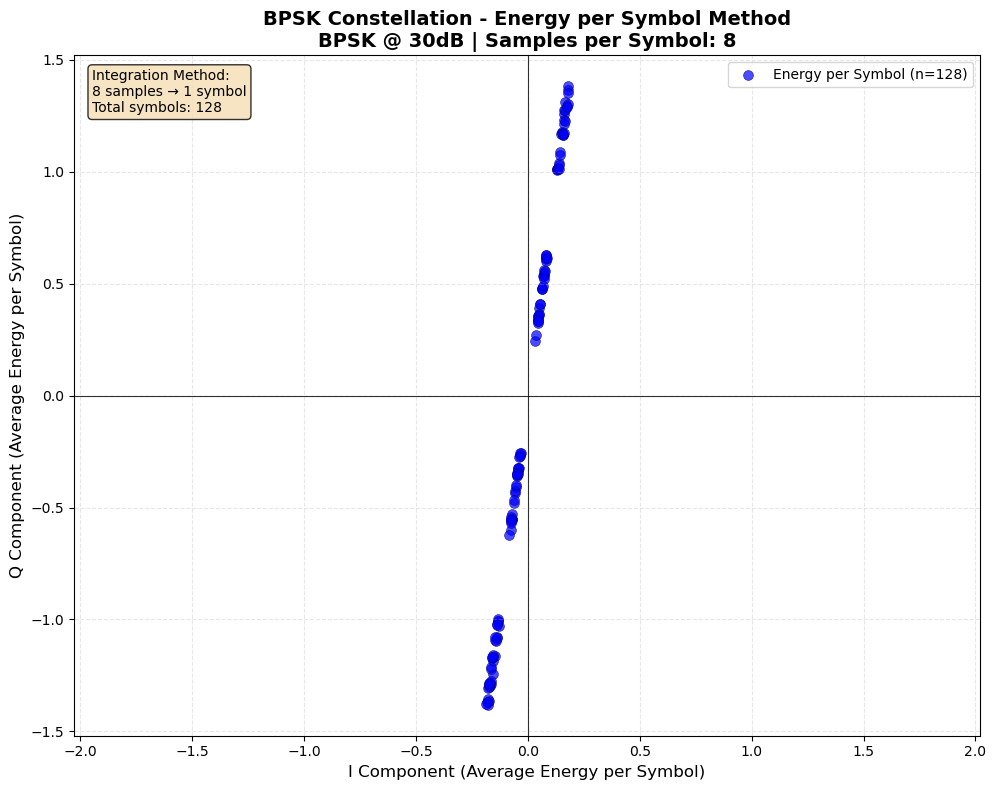

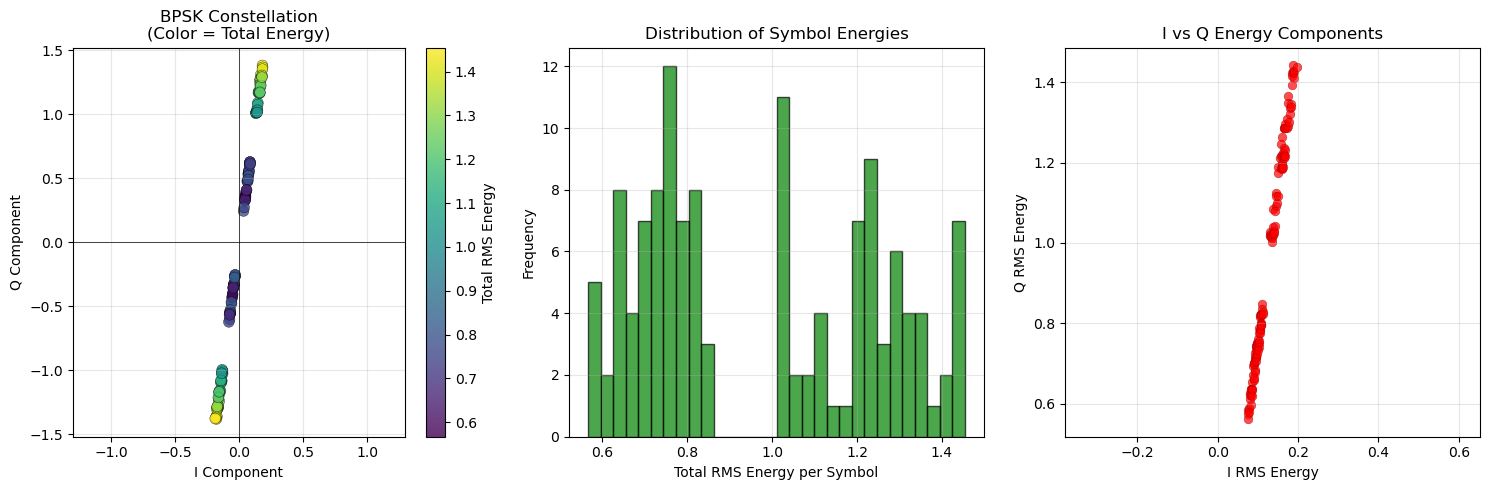

In [45]:
plt.figure(figsize=(10, 8))

# Main constellation plot
plt.scatter(I_constellation, Q_constellation, s=50, alpha=0.7, c='blue', 
           edgecolors='darkblue', linewidth=0.5, label=f'Energy per Symbol (n={len(I_constellation)})')

plt.title(f"BPSK Constellation - Energy per Symbol Method\n"
          f"{modulation_to_select} @ {snr_to_select}dB | "
          f"Samples per Symbol: {true_sps}", fontsize=14, fontweight='bold')
plt.xlabel("I Component (Average Energy per Symbol)", fontsize=12)
plt.ylabel("Q Component (Average Energy per Symbol)", fontsize=12)

# Add reference lines
plt.axhline(0, color='black', linewidth=0.8, alpha=0.8)
plt.axvline(0, color='black', linewidth=0.8, alpha=0.8)

# Add grid
plt.grid(True, alpha=0.3, linestyle='--')

# Set equal aspect ratio for proper constellation view
plt.axis('equal')

# Add legend and statistics box
legend_text = f'Integration Method:\n8 samples → 1 symbol\nTotal symbols: {len(I_constellation)}'
plt.text(0.02, 0.98, legend_text, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=10)

plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

# --- Additional Analysis Plot: Energy Distribution ---
plt.figure(figsize=(15, 5))

# Plot 1: I vs Q constellation with color-coded energy
plt.subplot(1, 3, 1)
scatter = plt.scatter(I_constellation, Q_constellation, s=60, c=total_rms_energy, 
                     cmap='viridis', alpha=0.8, edgecolors='black', linewidth=0.3)
plt.colorbar(scatter, label='Total RMS Energy')
plt.title(f"BPSK Constellation\n(Color = Total Energy)")
plt.xlabel("I Component")
plt.ylabel("Q Component")
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Plot 2: Energy distribution histogram
plt.subplot(1, 3, 2)
plt.hist(total_rms_energy, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.title("Distribution of Symbol Energies")
plt.xlabel("Total RMS Energy per Symbol")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

# Plot 3: I vs Q energy correlation
plt.subplot(1, 3, 3)
plt.scatter(I_rms_energy, Q_rms_energy, s=40, alpha=0.7, c='red', edgecolors='darkred', linewidth=0.3)
plt.title("I vs Q Energy Components")
plt.xlabel("I RMS Energy")
plt.ylabel("Q RMS Energy")
plt.grid(True, alpha=0.3)
plt.axis('equal')

plt.tight_layout()
plt.show()

In [46]:

def clean_bpsk_constellation_amplitude(I_constellation, Q_constellation, amplitude_factor=0.7):
    """
    Amplitude-based cleaning method: Remove points with low amplitude (close to origin).
    This method effectively removes transitional/middle data by keeping only high-energy symbols.
    
    Args:
        I_constellation, Q_constellation: Constellation points
        amplitude_factor: Factor of mean amplitude to use as threshold (default: 0.7)
    
    Returns:
        tuple: (I_clean, Q_clean, amplitudes_clean, amplitude_threshold)
    """
    # Calculate amplitude for each point
    amplitudes = np.sqrt(I_constellation**2 + Q_constellation**2)
    
    # Use statistical approach: remove points below threshold
    min_amplitude = np.mean(amplitudes) * amplitude_factor
    
    # Keep points with sufficient amplitude
    valid_indices = amplitudes >= min_amplitude
    
    I_clean = I_constellation[valid_indices]
    Q_clean = Q_constellation[valid_indices]
    amplitudes_clean = amplitudes[valid_indices]
    
    print(f"\nAmplitude-based BPSK Cleaning:")
    print(f"Mean amplitude: {np.mean(amplitudes):.4f}")
    print(f"Amplitude threshold: {min_amplitude:.4f}")
    print(f"Original points: {len(I_constellation)}")
    print(f"Cleaned points: {len(I_clean)}")
    print(f"Removed points: {len(I_constellation) - len(I_clean)} ({100*(len(I_constellation) - len(I_clean))/len(I_constellation):.1f}%)")
    
    return I_clean, Q_clean, amplitudes_clean, min_amplitude

def analyze_bpsk_clusters(I_clean, Q_clean):
    """
    Analyze the cleaned BPSK constellation to identify symbol characteristics.
    
    Returns:
        dict: Analysis results including cluster statistics
    """
    # Simple clustering based on I-component sign for BPSK
    positive_I_mask = I_clean > 0
    negative_I_mask = I_clean <= 0
    
    # Group 1: Positive I (typically Symbol 0: +1)
    I_pos = I_clean[positive_I_mask]
    Q_pos = Q_clean[positive_I_mask]
    
    # Group 2: Negative I (typically Symbol 1: -1)  
    I_neg = I_clean[negative_I_mask]
    Q_neg = Q_clean[negative_I_mask]
    
    results = {
        'symbol_0': {
            'count': len(I_pos),
            'I_mean': np.mean(I_pos) if len(I_pos) > 0 else 0,
            'Q_mean': np.mean(Q_pos) if len(Q_pos) > 0 else 0,
            'I_std': np.std(I_pos) if len(I_pos) > 0 else 0,
            'Q_std': np.std(Q_pos) if len(Q_pos) > 0 else 0,
        },
        'symbol_1': {
            'count': len(I_neg),
            'I_mean': np.mean(I_neg) if len(I_neg) > 0 else 0,
            'Q_mean': np.mean(Q_neg) if len(Q_neg) > 0 else 0,
            'I_std': np.std(I_neg) if len(I_neg) > 0 else 0,
            'Q_std': np.std(Q_neg) if len(Q_neg) > 0 else 0,
        }
    }
    
    return results



=== BPSK CONSTELLATION CLEANING ===
Input constellation points: 128

--- Amplitude-Based Cleaning Method ---

Amplitude-based BPSK Cleaning:
Mean amplitude: 0.8253
Amplitude threshold: 0.5777
Original points: 128
Cleaned points: 73
Removed points: 55 (43.0%)


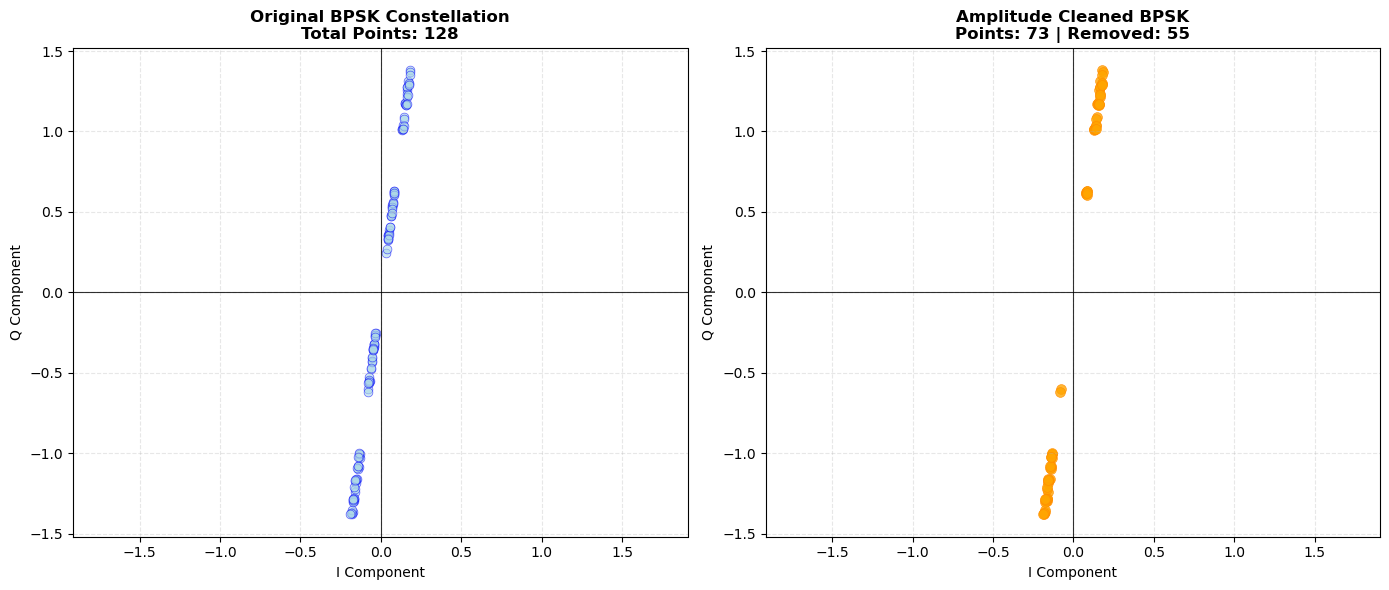

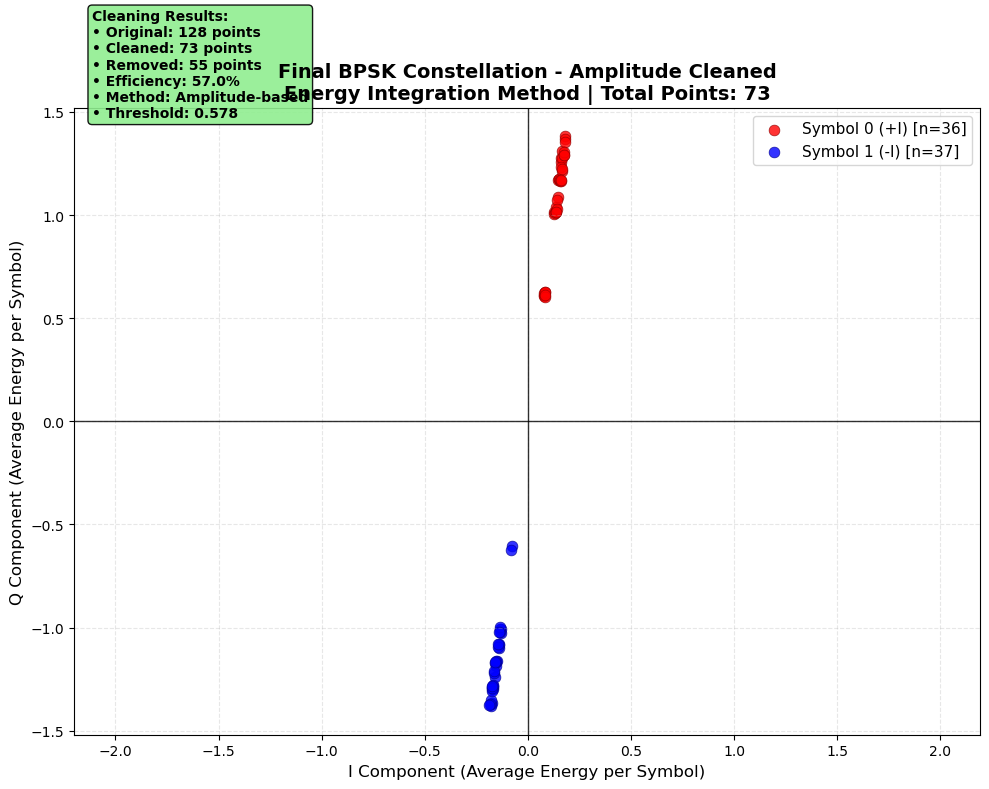


BPSK CONSTELLATION CLEANING SUMMARY
Original constellation points: 128
Amplitude cleaned points: 73 (57.0%)
Points removed: 55
Amplitude threshold used: 0.5777

BPSK Symbol Analysis:
  Symbol 0 (+I quadrant): 36 points
    Average position: I = 0.1417, Q = 1.0722
    Standard deviation: I = 0.0327, Q = 0.2471
  Symbol 1 (-I quadrant): 37 points
    Average position: I = -0.1545, Q = -1.1691
    Standard deviation: I = 0.0242, Q = 0.1789

Symbol separation distance: 2.2608
Symbol 0 magnitude: 1.0815
Symbol 1 magnitude: 1.1793
Average symbol magnitude: 1.1304


In [47]:
# ========================================================================
# MAIN CLEANING EXECUTION - Amplitude-Based Method Only
# ========================================================================

# Check if constellation data exists from previous analysis
if 'I_constellation' not in locals() or 'Q_constellation' not in locals():
    print("ERROR: Constellation data not found!")
    print("Please run the main BPSK constellation analysis code first.")
    print("Required variables: I_constellation, Q_constellation")
else:
    print("=== BPSK CONSTELLATION CLEANING ===")
    print(f"Input constellation points: {len(I_constellation)}")
    
    # --- Apply Amplitude-Based Cleaning ---
    print("\n--- Amplitude-Based Cleaning Method ---")
    I_clean, Q_clean, amplitudes_clean, amplitude_threshold = clean_bpsk_constellation_amplitude(I_constellation, Q_constellation)
    
    # --- Analyze the cleaned constellation ---
    cluster_analysis = analyze_bpsk_clusters(I_clean, Q_clean)
    
    # --- Visualization: Before vs After ---
    
    plt.figure(figsize=(14, 6))
    
    # Plot 1: Original constellation
    plt.subplot(1, 2, 1)
    plt.scatter(I_constellation, Q_constellation, s=40, alpha=0.6, c='lightblue', 
               edgecolors='blue', linewidth=0.5)
    plt.title(f"Original BPSK Constellation\n"
              f"Total Points: {len(I_constellation)}", fontsize=12, fontweight='bold')
    plt.xlabel("I Component", fontsize=10)
    plt.ylabel("Q Component", fontsize=10)
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.8)
    plt.axvline(0, color='black', linewidth=0.8, alpha=0.8)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.axis('equal')
    
    # Plot 2: Amplitude cleaned constellation
    plt.subplot(1, 2, 2)
    plt.scatter(I_clean, Q_clean, s=50, alpha=0.8, c='orange', 
               edgecolors='darkorange', linewidth=0.5)
    plt.title(f"Amplitude Cleaned BPSK\n"
              f"Points: {len(I_clean)} | Removed: {len(I_constellation) - len(I_clean)}", 
              fontsize=12, fontweight='bold')
    plt.xlabel("I Component", fontsize=10)
    plt.ylabel("Q Component", fontsize=10)
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.8)
    plt.axvline(0, color='black', linewidth=0.8, alpha=0.8)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.axis('equal')
    
    plt.tight_layout()
    plt.show()
    
    # --- Final Cleaned Constellation (Main Result) ---
    
    plt.figure(figsize=(10, 8))
    
    # Separate symbols based on I-component sign for better visualization
    positive_I_mask = I_clean > 0
    negative_I_mask = I_clean <= 0
    
    # Plot each symbol group with different colors
    plt.scatter(I_clean[positive_I_mask], Q_clean[positive_I_mask], 
               s=60, alpha=0.8, c='red', edgecolors='darkred', linewidth=0.5,
               label=f'Symbol 0 (+I) [n={np.sum(positive_I_mask)}]')
    
    plt.scatter(I_clean[negative_I_mask], Q_clean[negative_I_mask], 
               s=60, alpha=0.8, c='blue', edgecolors='darkblue', linewidth=0.5,
               label=f'Symbol 1 (-I) [n={np.sum(negative_I_mask)}]')
    
    plt.title(f"Final BPSK Constellation - Amplitude Cleaned\n"
              f"Energy Integration Method | Total Points: {len(I_clean)}", 
              fontsize=14, fontweight='bold')
    plt.xlabel("I Component (Average Energy per Symbol)", fontsize=12)
    plt.ylabel("Q Component (Average Energy per Symbol)", fontsize=12)
    
    plt.axhline(0, color='black', linewidth=1, alpha=0.8)
    plt.axvline(0, color='black', linewidth=1, alpha=0.8)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.axis('equal')
    
    # Add detailed statistics box
    stats_text = f'Cleaning Results:\n' \
                f'• Original: {len(I_constellation)} points\n' \
                f'• Cleaned: {len(I_clean)} points\n' \
                f'• Removed: {len(I_constellation) - len(I_clean)} points\n' \
                f'• Efficiency: {100*len(I_clean)/len(I_constellation):.1f}%\n' \
                f'• Method: Amplitude-based\n' \
                f'• Threshold: {amplitude_threshold:.3f}'
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9),
             fontsize=10, fontweight='bold')
    
    plt.legend(loc='upper right', fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # --- Summary Report ---
    
    print("\n" + "="*60)
    print("BPSK CONSTELLATION CLEANING SUMMARY")
    print("="*60)
    print(f"Original constellation points: {len(I_constellation)}")
    print(f"Amplitude cleaned points: {len(I_clean)} ({100*len(I_clean)/len(I_constellation):.1f}%)")
    print(f"Points removed: {len(I_constellation) - len(I_clean)}")
    print(f"Amplitude threshold used: {amplitude_threshold:.4f}")
    
    print(f"\nBPSK Symbol Analysis:")
    symbol_0 = cluster_analysis['symbol_0']
    symbol_1 = cluster_analysis['symbol_1']
    
    print(f"  Symbol 0 (+I quadrant): {symbol_0['count']} points")
    print(f"    Average position: I = {symbol_0['I_mean']:.4f}, Q = {symbol_0['Q_mean']:.4f}")
    print(f"    Standard deviation: I = {symbol_0['I_std']:.4f}, Q = {symbol_0['Q_std']:.4f}")
    
    print(f"  Symbol 1 (-I quadrant): {symbol_1['count']} points")  
    print(f"    Average position: I = {symbol_1['I_mean']:.4f}, Q = {symbol_1['Q_mean']:.4f}")
    print(f"    Standard deviation: I = {symbol_1['I_std']:.4f}, Q = {symbol_1['Q_std']:.4f}")
    
    if symbol_0['count'] > 0 and symbol_1['count'] > 0:
        symbol_separation = np.sqrt((symbol_0['I_mean'] - symbol_1['I_mean'])**2 + 
                                   (symbol_0['Q_mean'] - symbol_1['Q_mean'])**2)
        print(f"\nSymbol separation distance: {symbol_separation:.4f}")
        
        # Calculate average symbol magnitude
        mag_0 = np.sqrt(symbol_0['I_mean']**2 + symbol_0['Q_mean']**2)
        mag_1 = np.sqrt(symbol_1['I_mean']**2 + symbol_1['Q_mean']**2)
        print(f"Symbol 0 magnitude: {mag_0:.4f}")
        print(f"Symbol 1 magnitude: {mag_1:.4f}")
        print(f"Average symbol magnitude: {(mag_0 + mag_1)/2:.4f}")
    
    print("="*60)

=== Simple BPSK Visualization: 128 Samples ===
Processed 128 samples → 11 constellation points


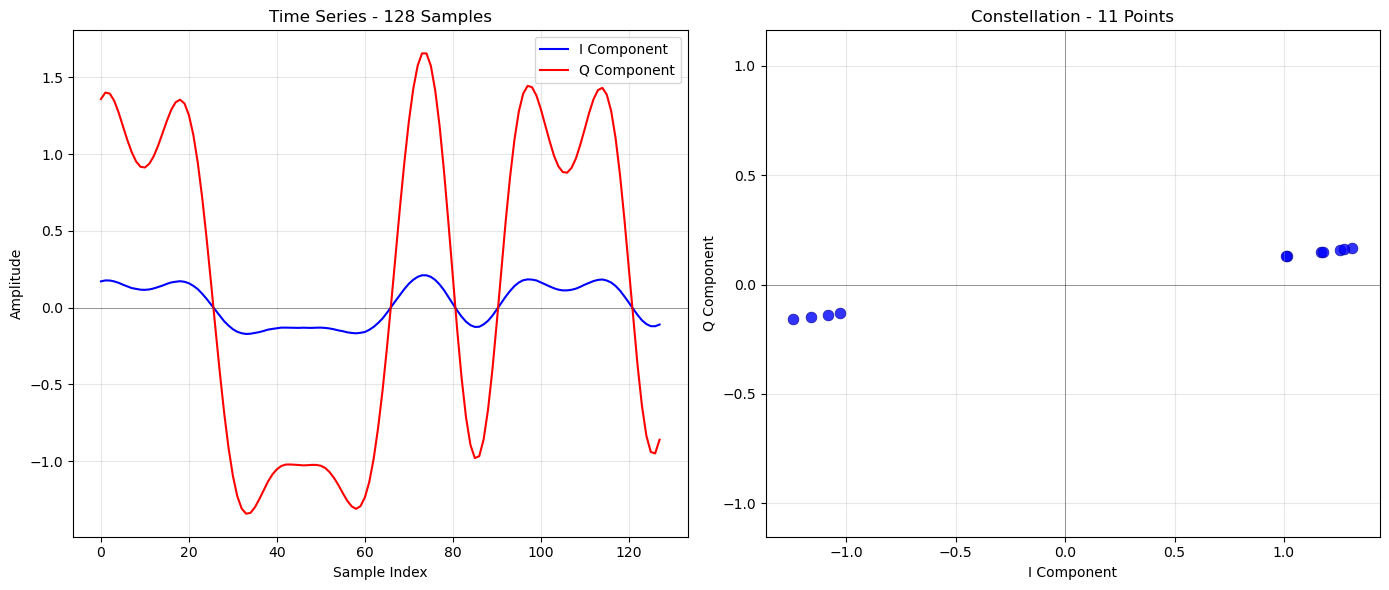

✅ Simple visualization complete: 128 samples → 11 points


In [57]:
# Number of samples to analyze (both time series AND constellation)
N_SAMPLES = 128  
true_sps = 8  # Samples per symbol (should match your main analysis)

# Check if required data exists
if 'I_full_frame' not in locals() or 'Q_full_frame' not in locals():
    print("ERROR: Required data not found!")
    print("Please run the main BPSK analysis code first.")
else:
    print(f"=== Simple BPSK Visualization: {N_SAMPLES} Samples ===")
    
    # Extract first 50 samples
    I_50samples = I_full_frame[:N_SAMPLES]
    Q_50samples = Q_full_frame[:N_SAMPLES]
    
    # Calculate constellation from these 50 samples
    num_complete_symbols = N_SAMPLES // true_sps
    usable_samples = num_complete_symbols * true_sps
    
    if num_complete_symbols > 0:
        # Energy integration to create constellation
        I_truncated = I_50samples[:usable_samples]
        Q_truncated = Q_50samples[:usable_samples]
        
        I_reshaped = I_truncated.reshape(num_complete_symbols, true_sps)
        Q_reshaped = Q_truncated.reshape(num_complete_symbols, true_sps)
        
        I_constellation_50 = np.mean(I_reshaped, axis=1)
        Q_constellation_50 = np.mean(Q_reshaped, axis=1)
        
        # Apply amplitude cleaning
        amplitudes_50 = np.sqrt(I_constellation_50**2 + Q_constellation_50**2)
        amplitude_threshold = np.mean(amplitudes_50) * 0.7
        valid_indices = amplitudes_50 >= amplitude_threshold
        
        # Swap I and Q to correct the reversed data
        I_clean_50 = Q_constellation_50[valid_indices]  # Use Q data for I
        Q_clean_50 = I_constellation_50[valid_indices]  # Use I data for Q
        
        print(f"Processed {usable_samples} samples → {len(I_clean_50)} constellation points")
        
        # Simple side-by-side plot
        plt.figure(figsize=(14, 6))
        
        # LEFT: Time Series
        plt.subplot(1, 2, 1)
        plt.plot(I_50samples, 'b-', linewidth=1.5, label='I Component')
        plt.plot(Q_50samples, 'r-', linewidth=1.5, label='Q Component')
        plt.title(f'Time Series - {N_SAMPLES} Samples')
        plt.xlabel('Sample Index')
        plt.ylabel('Amplitude')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.axhline(0, color='black', linewidth=0.5, alpha=0.5)
        
        # RIGHT: Constellation
        plt.subplot(1, 2, 2)
        plt.scatter(I_clean_50, Q_clean_50, s=60, alpha=0.8, c='blue', 
                   edgecolors='darkblue', linewidth=0.5)
        plt.title(f'Constellation - {len(I_clean_50)} Points')
        plt.xlabel('I Component')
        plt.ylabel('Q Component')
        plt.grid(True, alpha=0.3)
        plt.axhline(0, color='black', linewidth=0.5, alpha=0.5)
        plt.axvline(0, color='black', linewidth=0.5, alpha=0.5)
        plt.axis('equal')
        
        plt.tight_layout()
        plt.show()
        
        print(f"✅ Simple visualization complete: {usable_samples} samples → {len(I_clean_50)} points")
    
    else:
        print("ERROR: Not enough samples for even one symbol!")

=== BPSK SNR Comparison ===
Loading SNR 0dB data...
  SNR 0dB: 13 constellation points
Loading SNR 30dB data...
  SNR 30dB: 11 constellation points


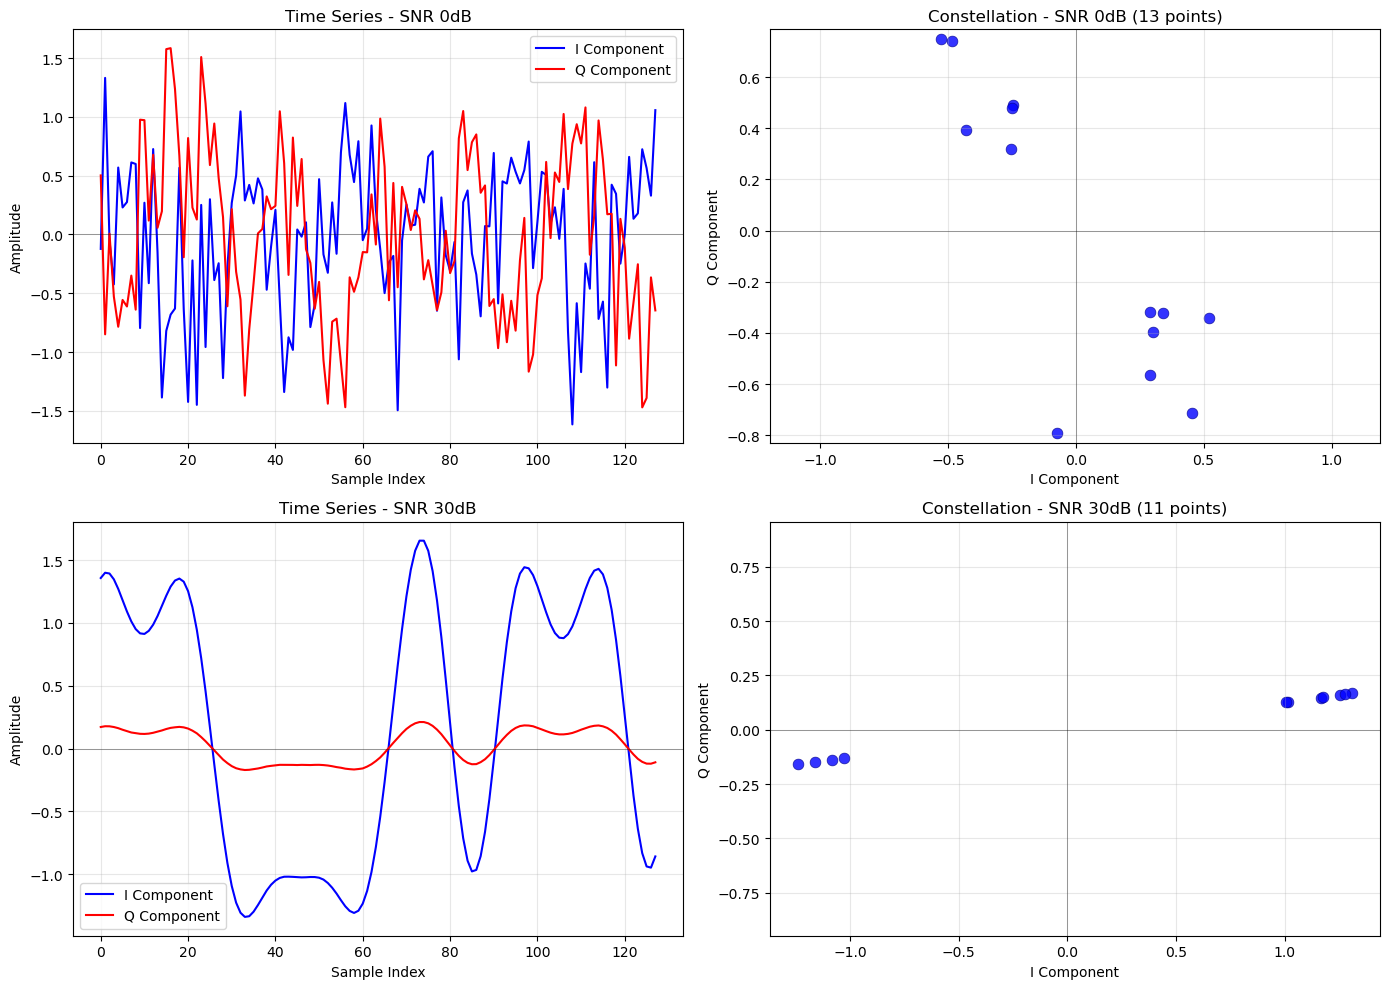

In [59]:
# Configuration
SNR_LEVELS = [0, 30]  # SNR levels to compare
N_SAMPLES = 128
true_sps = 8
modulation_to_select = 'BPSK'

def load_snr_data(snr_level):
    """Load BPSK data for specific SNR level"""
    try:
        # Find indices for the specific SNR
        idxs = find_modulation_snr_indices(modulation_to_select, snr_level, fixed_classes, Y_arr, Z_arr)
        if len(idxs) == 0:
            print(f"No data found for {modulation_to_select} @ {snr_level}dB")
            return None, None
        
        # Load I/Q data for this SNR
        with h5py.File(FILE_PATH, 'r') as f:
            X_ds = f['X']
            frame_iq = X_ds[idxs[0], :, :]
        
        # Extract I and Q (corrected order based on previous analysis)
        I_frame = frame_iq[:, 1]  # Swapped: use column 1 for I
        Q_frame = frame_iq[:, 0]  # Swapped: use column 0 for Q
        
        return I_frame, Q_frame
        
    except Exception as e:
        print(f"Error loading SNR {snr_level}dB data: {e}")
        return None, None

def process_constellation(I_frame, Q_frame, n_samples=50):
    """Process constellation from I/Q data"""
    if I_frame is None or Q_frame is None:
        return None, None
    
    # Use first n_samples
    I_samples = I_frame[:n_samples]
    Q_samples = Q_frame[:n_samples]
    
    # Calculate constellation
    num_complete_symbols = n_samples // true_sps
    usable_samples = num_complete_symbols * true_sps
    
    if num_complete_symbols > 0:
        I_truncated = I_samples[:usable_samples]
        Q_truncated = Q_samples[:usable_samples]
        
        I_reshaped = I_truncated.reshape(num_complete_symbols, true_sps)
        Q_reshaped = Q_truncated.reshape(num_complete_symbols, true_sps)
        
        I_constellation = np.mean(I_reshaped, axis=1)
        Q_constellation = np.mean(Q_reshaped, axis=1)
        
        # Apply amplitude cleaning
        amplitudes = np.sqrt(I_constellation**2 + Q_constellation**2)
        amplitude_threshold = np.mean(amplitudes) * 0.7
        valid_indices = amplitudes >= amplitude_threshold
        
        I_clean = I_constellation[valid_indices]
        Q_clean = Q_constellation[valid_indices]
        
        return I_clean, Q_clean
    
    return None, None

# Check if required data exists
required_vars = ['FILE_PATH', 'find_modulation_snr_indices', 'fixed_classes', 'Y_arr', 'Z_arr']
missing_vars = [var for var in required_vars if var not in locals()]

if missing_vars:
    print("ERROR: Required data not found!")
    print(f"Missing variables: {missing_vars}")
    print("Please run the main BPSK analysis code first.")
else:
    print("=== BPSK SNR Comparison ===")
    
    # Load data for different SNR levels
    snr_data = {}
    for snr in SNR_LEVELS:
        print(f"Loading SNR {snr}dB data...")
        I_frame, Q_frame = load_snr_data(snr)
        I_clean, Q_clean = process_constellation(I_frame, Q_frame, N_SAMPLES)
        
        snr_data[snr] = {
            'I_frame': I_frame,
            'Q_frame': Q_frame,
            'I_clean': I_clean,
            'Q_clean': Q_clean
        }
        
        if I_clean is not None:
            print(f"  SNR {snr}dB: {len(I_clean)} constellation points")
        else:
            print(f"  SNR {snr}dB: No valid data")
    
    # Create comparison plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for i, snr in enumerate(SNR_LEVELS):
        data = snr_data[snr]
        
        if data['I_frame'] is not None:
            # Time Series Plot
            ax_time = axes[i, 0]
            I_samples = data['I_frame'][:N_SAMPLES]
            Q_samples = data['Q_frame'][:N_SAMPLES]
            
            ax_time.plot(I_samples, 'b-', linewidth=1.5, label='I Component')
            ax_time.plot(Q_samples, 'r-', linewidth=1.5, label='Q Component')
            ax_time.set_title(f'Time Series - SNR {snr}dB')
            ax_time.set_xlabel('Sample Index')
            ax_time.set_ylabel('Amplitude')
            ax_time.grid(True, alpha=0.3)
            ax_time.legend()
            ax_time.axhline(0, color='black', linewidth=0.5, alpha=0.5)
            
            # Constellation Plot
            ax_const = axes[i, 1]
            if data['I_clean'] is not None:
                ax_const.scatter(data['I_clean'], data['Q_clean'], s=60, alpha=0.8, 
                               c='blue', edgecolors='darkblue', linewidth=0.5)
                ax_const.set_title(f'Constellation - SNR {snr}dB ({len(data["I_clean"])} points)')
            else:
                ax_const.set_title(f'Constellation - SNR {snr}dB (No data)')
                
            ax_const.set_xlabel('I Component')
            ax_const.set_ylabel('Q Component')
            ax_const.grid(True, alpha=0.3)
            ax_const.axhline(0, color='black', linewidth=0.5, alpha=0.5)
            ax_const.axvline(0, color='black', linewidth=0.5, alpha=0.5)
            ax_const.axis('equal')
            
        else:
            # No data available
            axes[i, 0].text(0.5, 0.5, f'No data for SNR {snr}dB', 
                           ha='center', va='center', transform=axes[i, 0].transAxes)
            axes[i, 0].set_title(f'Time Series - SNR {snr}dB')
            
            axes[i, 1].text(0.5, 0.5, f'No data for SNR {snr}dB', 
                           ha='center', va='center', transform=axes[i, 1].transAxes)
            axes[i, 1].set_title(f'Constellation - SNR {snr}dB')
    
    plt.tight_layout()
    plt.show()